In [ ]:
pip install pandas numpy torch torchvision torchaudio transformers datasets huggingface_hub scikit-learn matplotlib seaborn tqdm pyvi psutil joblib tensorflow

In [3]:
import os
import time
import torch
import joblib
import re
import psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import threading
import transformers
import warnings

# Suppress unnecessary warnings
warnings.filterwarnings('ignore')
transformers.logging.set_verbosity_error()

from tqdm.notebook import tqdm
from pyvi import ViTokenizer
from datasets import load_dataset
from huggingface_hub import hf_hub_download, scan_cache_dir
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Device Detection
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Execution Device: {device.type.upper()}")
MAX_LEN = 256

class ResourceTracker:
    """Tracks Peak System RAM and GPU VRAM usage during execution"""
    def __init__(self):
        self.peak_ram = 0
        self.peak_vram = 0
        self.running = False
        self.process = psutil.Process(os.getpid())

    def _track(self):
        while self.running:
            try:
                # Track System RAM
                current_ram = self.process.memory_info().rss / (1024 * 1024)
                if current_ram > self.peak_ram: self.peak_ram = current_ram
                # Track GPU VRAM
                if torch.cuda.is_available():
                    current_vram = torch.cuda.max_memory_allocated() / (1024 * 1024)
                    if current_vram > self.peak_vram: self.peak_vram = current_vram
            except: pass
            time.sleep(0.05)

    def start(self):
        self.peak_ram = 0
        self.peak_vram = 0
        self.running = True
        if torch.cuda.is_available(): torch.cuda.reset_peak_memory_stats()
        self.thread = threading.Thread(target=self._track, daemon=True)
        self.thread.start()

    def stop(self):
        self.running = False
        time.sleep(0.1)
        return self.peak_ram, self.peak_vram

def get_hf_model_size(repo_id):
    """Calculates model size on disk from Hugging Face cache"""
    try:
        cache_info = scan_cache_dir()
        for repo in cache_info.repos:
            if repo.repo_id == repo_id: return repo.size_on_disk / (1024 * 1024)
    except: return 0
    return 0

Execution Device: CUDA


In [4]:
print("--- Preparing Test Dataset ---")
dataset = load_dataset("pqthinh232/vietnamese-restaurant-review-sentiment-dataset")
df_test = pd.DataFrame(dataset['test'])

def preprocess_text(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    tokens = ViTokenizer.tokenize(text).split()
    return " ".join(tokens[:MAX_LEN])

df_test['clean_review'] = df_test['review'].apply(preprocess_text)
df_test['word_count'] = df_test['clean_review'].apply(lambda x: len(x.split()))
X_test_text = df_test['clean_review'].tolist()
y_true = df_test['label'].tolist()

# Define English labels
TARGET_NAMES = ["Negative (0)", "Positive (1)", "Neutral (2)"]

# Group by length for robustness analysis
df_test['len_group'] = pd.cut(df_test['word_count'], bins=[0, 20, 60, 257], labels=['Short', 'Medium', 'Long'])

--- Preparing Test Dataset ---


In [5]:
results_map = {}
tracker = ResourceTracker()

def evaluate_model(name, repo, files, is_transformer=False):
    print(f"\n>>> Benchmarking {name}...")
    paths = []
    total_disk = 0

    # 1. Loading & Storage Metrics
    if not is_transformer:
        for f in files:
            p = hf_hub_download(repo_id=repo, filename=f)
            paths.append(p)
            total_disk += os.path.getsize(p) / (1024 * 1024)
    else:
        tokenizer = AutoTokenizer.from_pretrained(repo)
        model = AutoModelForSequenceClassification.from_pretrained(repo).to(device)
        total_disk = get_hf_model_size(repo)

    # 2. Start Inference with Resource Tracking
    tracker.start()
    start_time = time.time()
    y_pred = []

    if name == "SVM":
        svm_model = joblib.load(paths[0])
        tfidf = joblib.load(paths[1])
        y_pred = svm_model.predict(tfidf.transform(X_test_text))
    elif name == "BiGRU":
        bg_model = load_model(paths[0])
        with open(paths[1], "rb") as f: tok_bg = pickle.load(f)
        seq = pad_sequences(tok_bg.texts_to_sequences(X_test_text), maxlen=MAX_LEN, padding='post')
        y_pred = np.argmax(bg_model.predict(seq, verbose=0), axis=1)
    else: # PhoBERT
        batch_size = 32
        for i in tqdm(range(0, len(X_test_text), batch_size), desc=f"{name} GPU Inference"):
            batch = X_test_text[i : i + batch_size]
            inputs = tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=MAX_LEN).to(device)
            with torch.no_grad():
                outputs = model(**inputs)
                y_pred.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())

    duration = time.time() - start_time
    latency = (duration / len(y_true)) * 1000
    peak_ram, peak_vram = tracker.stop()

    # 3. Save Detailed Results
    results_map[name] = {
        'preds': y_pred, 'latency': latency, 'ram': peak_ram, 'vram': peak_vram, 'disk': total_disk,
        'report_dict': classification_report(y_true, y_pred, target_names=TARGET_NAMES, output_dict=True),
        'report_text': classification_report(y_true, y_pred, target_names=TARGET_NAMES)
    }

In [6]:
# Evaluate SVM
evaluate_model("SVM", "neidythedev/vietnamese-restaurant-sentiment-svm", ["svm_sentiment_model.pkl", "tfidf_vectorizer.pkl"])

# Evaluate BiGRU
evaluate_model("BiGRU", "ltro6125/HCMUS-bigru-vietnamese-restaurant-sentiment-analysis", ["vietnamese-restaurant-bigru.keras", "tokenizer.pkl"])

# Evaluate PhoBERT
evaluate_model("PhoBERT", "pqthinh232/HCMUS-phobert-vietnamese-restaurant-sentiment-analysis", [], is_transformer=True)


>>> Benchmarking SVM...

>>> Benchmarking BiGRU...

>>> Benchmarking PhoBERT...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

PhoBERT GPU Inference:   0%|          | 0/103 [00:00<?, ?it/s]

In [7]:
print("\n" + "="*70)
print("DETAILED CLASSIFICATION REPORTS PER MODEL")
print("="*70)
for name in results_map:
    print(f"\n[MODEL: {name}]")
    print(results_map[name]['report_text'])
    print("-" * 40)

# Create Summary Table
summary_data = []
for name, data in results_map.items():
    r = data['report_dict']
    summary_data.append({
        "Model": name,
        "Accuracy": r['accuracy'],
        "Macro F1": r['macro avg']['f1-score'],
        "Latency(ms)": data['latency'],
        "RAM(MB)": data['ram'],
        "VRAM(MB)": data['vram'],
        "Disk(MB)": data['disk']
    })

df_res = pd.DataFrame(summary_data)
print("\n" + "="*110)
print("CROSS-MODEL PERFORMANCE & RESOURCE SUMMARY")
print(df_res.to_string(index=False, float_format=lambda x: "{:.3f}".format(x)))
print("="*110)


DETAILED CLASSIFICATION REPORTS PER MODEL

[MODEL: SVM]
              precision    recall  f1-score   support

Negative (0)       0.87      0.86      0.86       622
Positive (1)       0.93      0.84      0.88      1981
 Neutral (2)       0.58      0.75      0.66       669

    accuracy                           0.82      3272
   macro avg       0.79      0.82      0.80      3272
weighted avg       0.85      0.82      0.83      3272

----------------------------------------

[MODEL: BiGRU]
              precision    recall  f1-score   support

Negative (0)       0.93      0.79      0.86       622
Positive (1)       0.92      0.88      0.90      1981
 Neutral (2)       0.59      0.75      0.66       669

    accuracy                           0.83      3272
   macro avg       0.81      0.81      0.80      3272
weighted avg       0.85      0.83      0.84      3272

----------------------------------------

[MODEL: PhoBERT]
              precision    recall  f1-score   support

Negative (

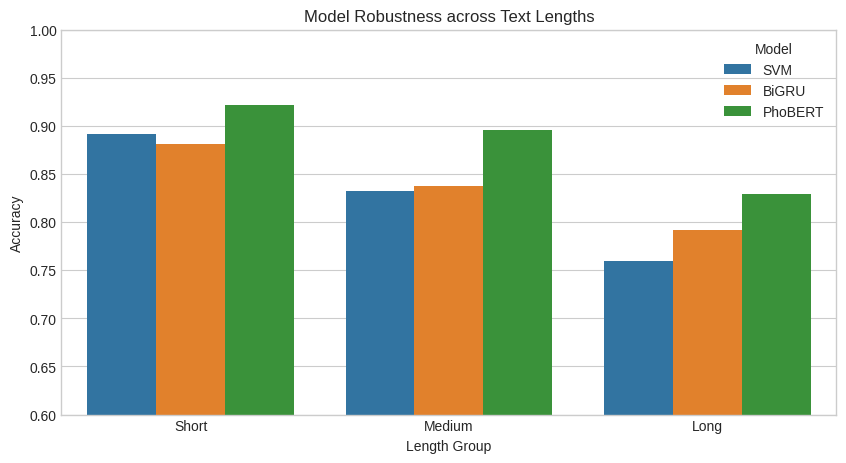

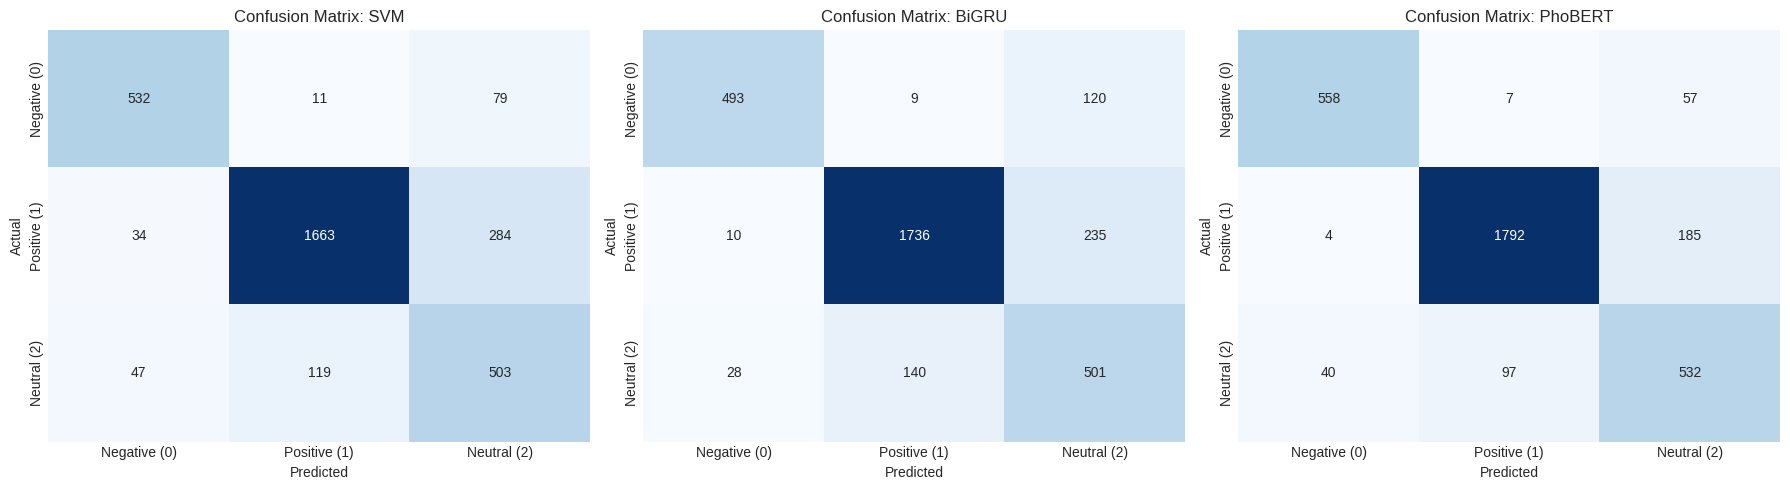

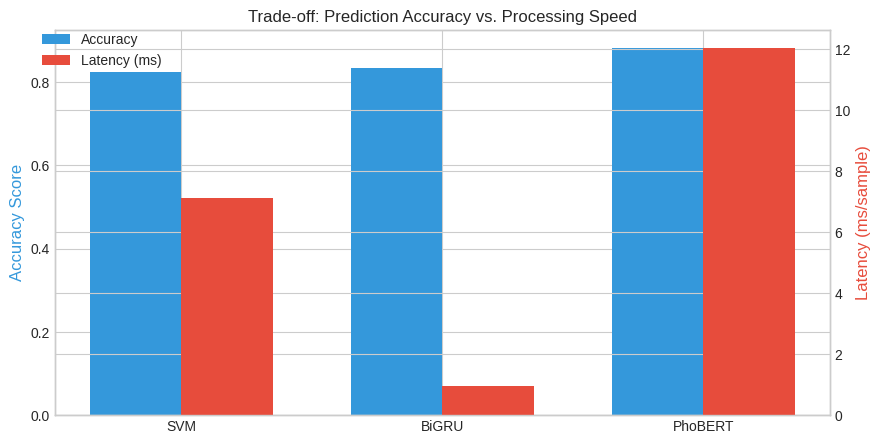

In [8]:
plt.style.use('seaborn-v0_8-whitegrid')

# 1. Accuracy vs Text Length
plt.figure(figsize=(10, 5))
len_res = []
for group in ['Short', 'Medium', 'Long']:
    subset = df_test[df_test['len_group'] == group]
    for name in results_map.keys():
        acc = accuracy_score(subset['label'], np.array(results_map[name]['preds'])[subset.index])
        len_res.append({"Length Group": group, "Model": name, "Accuracy": acc})
sns.barplot(data=pd.DataFrame(len_res), x='Length Group', y='Accuracy', hue='Model')
plt.title("Model Robustness across Text Lengths")
plt.ylim(0.6, 1.0)
plt.show()

# 2. Confusion Matrices (English Labels)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, name in enumerate(results_map.keys()):
    cm = confusion_matrix(y_true, results_map[name]['preds'])
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Blues', cbar=False,
                xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES)
    axes[i].set_title(f"Confusion Matrix: {name}")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")
plt.tight_layout()
plt.show()

# 3. Accuracy vs Latency Trade-off
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
x = np.arange(len(df_res['Model']))
width = 0.35

ax1.bar(x - width/2, df_res['Accuracy'], width, label='Accuracy', color='#3498db')
ax2.bar(x + width/2, df_res['Latency(ms)'], width, label='Latency (ms)', color='#e74c3c')

ax1.set_ylabel('Accuracy Score', color='#3498db', fontsize=12)
ax2.set_ylabel('Latency (ms/sample)', color='#e74c3c', fontsize=12)
plt.xticks(x, df_res['Model'])
plt.title("Trade-off: Prediction Accuracy vs. Processing Speed")
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
plt.show()